In [1]:
import sys
sys.path.append('../')
import warnings
warnings.filterwarnings("ignore")
# We import all our dependencies.
import numpy as np
import torch
from torch.utils.data import DataLoader
from models.lvae import LadderVAE
from boilerplate.dataloader import BCSSDataset, ModeAwareBalancedAnchorBatchSampler, flex_collate
import training
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob
import random
import torch
import matplotlib.pyplot as plt

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

data_dir = "/home/sheida.rahnamai/BCSS/"
img_paths = sorted(glob(data_dir+'images_vahadane/*.png'))
lbl_paths = sorted(glob(data_dir+'masks/*.png'))
imgs = list(np.array(Image.open(path)) for k, path in enumerate(img_paths))
lbls = list(np.array(Image.open(path)) for k, path in enumerate(lbl_paths))

In [3]:
use_wandb = True

patch_size = 32

gaussian_noise_std = None

model_name = "segmentation"
directory_path = "/group/jug/Sheida/HVAE/segmentation/test_BSCC/"

noiseModel = None

# Training-specific
batch_size = 256
lr = 3e-5
max_epochs = 1000
num_latents = 3
z_dims = [32] * int(num_latents)
blocks_per_layer = 5
batchnorm = False
free_bits = 0.0

alpha = 1  # weight of the inpainting loss
beta = 1e-2  # weight of the KL loss
gamma = 1  # weight of the contrastive loss

initial_mask_size = 1
final_mask_size = 1
initial_label_size =1
final_label_size = 1
step_interval = 100

contrastive_learning = True
margin = 50  # distance for negative pairs in contrastive learning
lambda_contrastive = 0.5  # weight of the positive pairs in contrastive learning
# (1-lambda_contrastive is the weight of the negative pairs)

mode = 'supervised' #or 'semisupervised' or 'unsupervised'
labeled_ratio = 1  # ratio of labeled data in semisupervised mode
stochastic_block_type = 'mixture'  # 'normal' or 'mixture'
conditional = True  # True for conditional LVAE (conditioned on gt label)
condition_type = 'mlp'  # 'mlp' or 'transformer'
assert (conditional == True and condition_type != None) or conditional == False
n_components = 19  # number of components for prior
n_classes = 19  # number of classes in the dataset
# train data
keys = list(range(105))

np.random.seed(42)
np.random.shuffle(keys)


# compute mean and std of the data
all_elements = np.concatenate([imgs[key].flatten() for key in keys])
data_mean = np.mean(all_elements)
data_std = np.std(all_elements.astype(np.float32))

sample_ratio = 20

# normalizing the data
for key in tqdm(keys, "Normalizing data"):
    imgs[key] = (imgs[key] - data_mean) / data_std

Normalizing data: 100%|██████████| 105/105 [00:07<00:00, 14.53it/s]


In [4]:
all_labels = set()
label_count = [0] * 21
for k in keys:
    uniq = np.unique(lbls[k])
    for l in uniq:
        label_count[l] += 1
    all_labels.update(uniq.tolist())

print("All unique labels across train dataset:", sorted(all_labels))
# for i, c in enumerate(label_count):
#     print(i, c)
print("Total classes:", len(all_labels))

All unique labels across train dataset: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20]
Total classes: 19


In [5]:
train_set = BCSSDataset(
    images=imgs,    
    labels=lbls,
    patch_size=patch_size,
    label_size=initial_label_size,
    mode='supervised',
    ratio=labeled_ratio,
)

[ 1  2  3  4  5  6  7  9 10 11 12 13 14 15 17 18 19 20]
  Class 1 (anchors): 1036 samples
  Class 2 (anchors): 1019 samples
  Class 3 (anchors): 1683 samples
  Class 4 (anchors): 1327 samples
  Class 5 (anchors): 946 samples
  Class 6 (anchors): 1193 samples
  Class 7 (anchors): 1323 samples
  Class 9 (anchors): 1123 samples
  Class 10 (anchors): 1070 samples
  Class 11 (anchors): 952 samples
  Class 13 (anchors): 865 samples
  Class 14 (anchors): 1015 samples
  Class 15 (anchors): 957 samples
  Class 17 (anchors): 1043 samples
  Class 18 (anchors): 1364 samples
  Class 19 (anchors): 1019 samples
  Class 20 (anchors): 1049 samples
  Class 1 (neighbors): 8956 samples
  Class 2 (neighbors): 13736 samples
  Class 3 (neighbors): 11388 samples
  Class 4 (neighbors): 9367 samples
  Class 5 (neighbors): 4540 samples
  Class 6 (neighbors): 6754 samples
  Class 7 (neighbors): 8503 samples
  Class 9 (neighbors): 7251 samples
  Class 10 (neighbors): 7103 samples
  Class 11 (neighbors): 6067 sampl

In [6]:
len(train_set)

18984

In [7]:
def plot_anchor_with_neighbors(ds: BCSSDataset, label: int, axsize=3, cmap="gray"):
    # Make sure we're in semisupervised mode (returns anchor + neighbors)
    if ds.mode != "semisupervised":
        ds.set_mode("semisupervised")

    # All indices whose anchor label == `label`
    idx_pool = ds.anchor_indices_by_label.get(label, [])
    if not idx_pool:
        raise ValueError(f"No anchors found for label {label}.")

    # Pick one at random
    idx = random.choice(idx_pool)

    # Fetch sample: patches [8,1,H,W], labels [8], segments [8,1,H,W], coords [8,2]
    patches, labels, segments, coords = ds[idx]  # tensors

    # Plot 2 x 4 grid
    fig, axes = plt.subplots(2, 4, figsize=(4*axsize, 2*axsize))
    axes = axes.ravel()

    for i in range(8):
        img = patches[i, 0].cpu().numpy()
        cy, cx = coords[i].tolist()
        lab = int(labels[i].item())

        ax = axes[i]
        ax.imshow(img, cmap=cmap)
        # mark the center pixel of the patch (relative center)
        h, w = img.shape
        ax.scatter([w//2], [h//2], s=20, marker='x')  # center mark
        title = "Anchor" if i == 0 else f"N{i}"
        ax.set_title(f"{title}\nlabel={lab}  (y={cy}, x={cx})", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9803948784423255..1.4565215311051278].


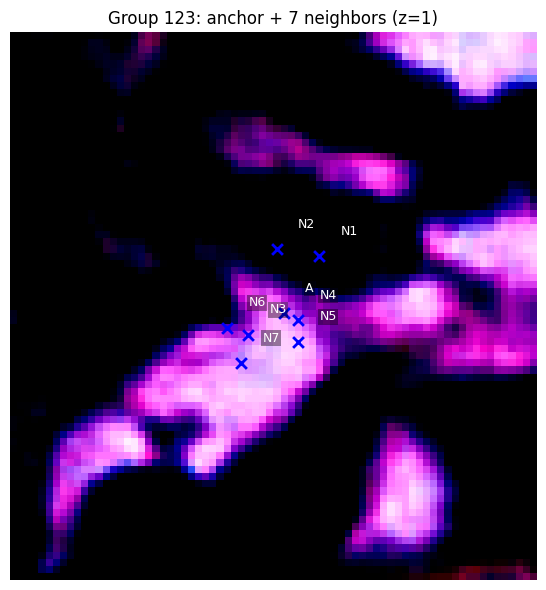

In [10]:
plot_group_all_in_one(train_set, idx=123, pad=30)

In [11]:
train_set.groups[123]

{'z': 1,
 'coords': [(530, 1422),
  (522, 1427),
  (521, 1421),
  (533, 1417),
  (531, 1424),
  (534, 1424),
  (532, 1414),
  (537, 1416)],
 'labels': [3, 3, 3, 3, 3, 3, 3, 3]}

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt

def _to_hwC(img):
    """Ensure image is (H,W,C) or (H,W) for imshow."""
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        # If it's (C,H,W) with small C, move channel last
        if img.shape[0] <= 4 and img.shape[0] < img.shape[1] and img.shape[0] < img.shape[2]:
            return np.transpose(img, (1, 2, 0))
        return img
    raise ValueError(f"Unexpected image shape {img.shape}")

def _rescale_for_display(img, robust=False, p_low=1, p_high=99):
    """
    Rescale to [0,1] for display.
    - robust=False: min-max per image (Fiji 'Auto' vibe).
    - robust=True: percentile [p_low, p_high] per channel.
    """
    img = img.astype(np.float32, copy=False)
    if img.ndim == 2:
        if robust:
            lo, hi = np.percentile(img, [p_low, p_high])
        else:
            lo, hi = img.min(), img.max()
        if hi > lo:
            img = (img - lo) / (hi - lo)
        else:
            img = np.zeros_like(img)
        return np.clip(img, 0, 1)

    # (H,W,C) — rescale per channel
    out = np.empty_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        ch = img[..., c]
        if robust:
            lo, hi = np.percentile(ch, [p_low, p_high])
        else:
            lo, hi = ch.min(), ch.max()
        if hi > lo:
            ch = (ch - lo) / (hi - lo)
        else:
            ch = np.zeros_like(ch)
        out[..., c] = np.clip(ch, 0, 1)
    return out

def plot_group_all_in_one(
    ds, idx=None, label=None, pad=30, cross_size=60, robust=True, p_low=1, p_high=99
):
    """
    Show one crop containing the anchor + 7 neighbors with blue 'x' at each center.
    - Auto rescales intensities for display (so normalized data looks like Fiji).
    - robust=True uses percentile stretch; set robust=False for plain min-max.
    """
    if idx is None:
        if label is None:
            raise ValueError("Provide either idx or label.")
        pool = ds.anchor_indices_by_label.get(label, [])
        if not pool:
            raise ValueError(f"No anchors found for label {label}.")
        idx = random.choice(pool)

    g = ds.groups[idx]
    z = int(g["z"])
    coords = np.array(g["coords"], dtype=int)  # [(y,x), ...]
    ys, xs = coords[:, 0], coords[:, 1]

    # Grab the raw normalized slice from dataset
    slice_img = ds.images[z]  # could be HxW, HxWxC, or CxHxW
    img_vis = _to_hwC(slice_img)
    H, W = img_vis.shape[:2]

    # Compute padded bbox
    y0 = max(0, ys.min() - pad)
    y1 = min(H - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad)
    x1 = min(W - 1, xs.max() + pad)

    # Crop and rescale for display
    crop = img_vis[y0:y1+1, x0:x1+1]
    crop_disp = _rescale_for_display(crop, robust=robust, p_low=p_low, p_high=p_high)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(crop_disp, cmap="gray" if crop_disp.ndim == 2 else None)
    ax.set_title(f"Group {idx}: anchor + 7 neighbors (z={z})")
    ax.axis("off")

    # Shift coords to crop space
    xs_c = xs - x0
    ys_c = ys - y0

    # --- Anchor (index 0) ---
    ax.scatter(xs_c[0], ys_c[0],
               marker='o', s=cross_size*2,  # larger red circle
               facecolors='none', edgecolors='red', linewidths=2,
               label='Anchor')

    # --- Neighbors (1..7) ---
    ax.scatter(xs_c[1:], ys_c[1:],
               marker='x', s=cross_size, linewidths=2,
               c='blue', label='Neighbors')



    plt.tight_layout()
    plt.show()


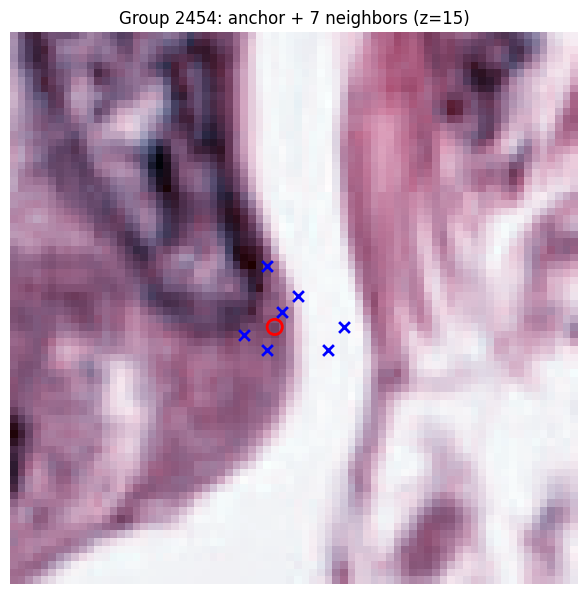

In [13]:
# Plain min–max (per image / channel)
plot_group_all_in_one(train_set, label=19, robust=False)

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- helpers ---
def _to_hwC(img):
    """Ensure image is (H,W,C) or (H,W) for imshow."""
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        # If it's (C,H,W) with small C, move channel last
        if img.shape[0] <= 4 and img.shape[0] < img.shape[1] and img.shape[0] < img.shape[2]:
            return np.transpose(img, (1, 2, 0))
        return img
    raise ValueError(f"Unexpected image shape {img.shape}")

def _rescale_for_display(img, robust=True, p_low=1, p_high=99):
    """Rescale to [0,1] (per-channel for RGB) for display."""
    img = img.astype(np.float32, copy=False)
    if img.ndim == 2:
        lo, hi = (np.percentile(img, [p_low, p_high]) if robust else (img.min(), img.max()))
        if hi > lo:
            img = (img - lo) / (hi - lo)
        else:
            img = np.zeros_like(img)
        return np.clip(img, 0, 1)
    out = np.empty_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        ch = img[..., c]
        lo, hi = (np.percentile(ch, [p_low, p_high]) if robust else (ch.min(), ch.max()))
        if hi > lo:
            ch = (ch - lo) / (hi - lo)
        else:
            ch = np.zeros_like(ch)
        out[..., c] = np.clip(ch, 0, 1)
    return out

# --- main ---
def plot_group_image_and_label(
    ds, idx=None, label=None, pad=30, cross_size=60,
    robust=True, p_low=1, p_high=99, show_colorbar=True
):
    """
    Two columns:
      [Left]  Image crop (auto-rescaled for display)
      [Right] Label map crop (same region), with same markers
    Anchor = red circle, Neighbors = blue 'x'. Label IDs are printed next to markers.
    """
    # pick a group
    if idx is None:
        if label is None:
            raise ValueError("Provide either idx or label.")
        pool = ds.anchor_indices_by_label.get(label, [])
        if not pool:
            raise ValueError(f"No anchors found for label {label}.")
        idx = random.choice(pool)

    g = ds.groups[idx]
    z = int(g["z"])
    coords = np.array(g["coords"], dtype=int)      # [(y,x), ...]
    labs_at_points = np.array(g["labels"], dtype=int)
    ys, xs = coords[:, 0], coords[:, 1]

    # image slice
    img_slice = ds.images[z]                       # HxW or HxWxC or CxHxW
    img_vis = _to_hwC(img_slice)
    H, W = img_vis.shape[:2]

    # label slice (assumed ZxHxW of ints)
    lbl_slice = ds.labels[z]                       # HxW (ints)
    if lbl_slice.ndim != 2:
        # If it's HxWx1, squeeze
        lbl_slice = np.squeeze(lbl_slice)
    assert lbl_slice.shape[:2] == (H, W), "Label slice shape must match image slice."

    # crop bbox
    y0 = max(0, ys.min() - pad)
    y1 = min(H - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad)
    x1 = min(W - 1, xs.max() + pad)

    # crops
    crop_img  = img_vis[y0:y1+1, x0:x1+1]
    crop_lbl  = lbl_slice[y0:y1+1, x0:x1+1]
    crop_disp = _rescale_for_display(crop_img, robust=robust, p_low=p_low, p_high=p_high)

    # coords in crop space
    xs_c = xs - x0
    ys_c = ys - y0

    # prepare a discrete colormap for labels
    uniq = np.unique(crop_lbl)
    # simple palette (extend if many classes)
    base_colors = plt.get_cmap("tab20").colors
    if len(uniq) > len(base_colors):
        # repeat if needed
        reps = (len(uniq) // len(base_colors)) + 1
        colors = (base_colors * reps)[:len(uniq)]
    else:
        colors = base_colors[:len(uniq)]
    label_to_idx = {val: i for i, val in enumerate(uniq)}
    mapped_lbl = np.vectorize(label_to_idx.get)(crop_lbl)
    discrete_cmap = ListedColormap(colors[:len(uniq)])

    # plot two columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    # left: image
    ax0 = axes[0]
    ax0.imshow(crop_disp, cmap="gray" if crop_disp.ndim == 2 else None)
    ax0.set_title(f"Image (z={z})")
    ax0.axis("off")

    # right: label map
    ax1 = axes[1]
    im = ax1.imshow(mapped_lbl, cmap=discrete_cmap, interpolation="nearest")
    ax1.set_title("Labels (same crop)")
    ax1.axis("off")
    if show_colorbar:
        # custom ticks with actual label IDs
        cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, ticks=np.arange(len(uniq)))
        cbar.ax.set_yticklabels([str(v) for v in uniq])

    # markers on BOTH axes
    # Anchor
    for ax in (ax0, ax1):
        ax.scatter(xs_c[0], ys_c[0], marker='o', s=cross_size*2,
                   facecolors='none', edgecolors='red', linewidths=2)
        # Neighbors
        ax.scatter(xs_c[1:], ys_c[1:], marker='x', s=cross_size,
                   linewidths=2, c='blue')


    plt.show()


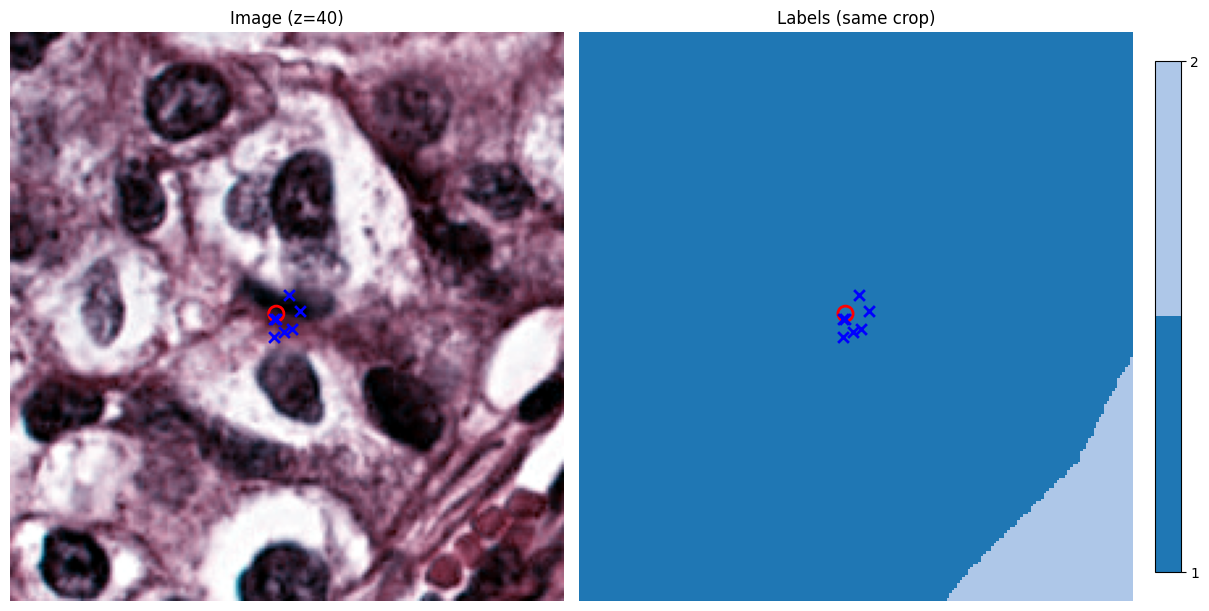

In [15]:
# Random group with a given anchor label
plot_group_image_and_label(train_set, label=1, pad=100)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
import random

def plot_full_and_crop_with_box(
    ds, idx=None, label=None, pad=30, cross_size=60,
    robust=True, p_low=1, p_high=99, show_colorbar=True,
    rect_color="red", rect_lw=2
):
    """
    2x2 figure:
      [0,0] Full image with black rectangle showing crop
      [0,1] Full label with same rectangle
      [1,0] Image crop with markers (anchor red circle, neighbors blue x)
      [1,1] Label crop with same markers (and optional colorbar)
    Intensities auto-rescaled for display; labels shown with discrete colormap.
    """
    # --- choose group ---
    if idx is None:
        if label is None:
            raise ValueError("Provide either idx or label.")
        pool = ds.anchor_indices_by_label.get(label, [])
        if not pool:
            raise ValueError(f"No anchors found for label {label}.")
        idx = random.choice(pool)

    g = ds.groups[idx]
    z = int(g["z"])
    coords = np.array(g["coords"], dtype=int)      # [(y,x), ...]
    labs_at_points = np.array(g["labels"], dtype=int)
    ys, xs = coords[:, 0], coords[:, 1]

    # --- get image & label slices ---
    img_slice = ds.images[z]                       # HxW or HxWxC or CxHxW
    img_vis = _to_hwC(img_slice)
    H, W = img_vis.shape[:2]

    lbl_slice = ds.labels[z]                       # HxW (ints)
    if lbl_slice.ndim != 2:
        lbl_slice = np.squeeze(lbl_slice)
    assert lbl_slice.shape[:2] == (H, W), "Label slice must match image slice."

    # --- crop bbox with padding ---
    y0 = max(0, ys.min() - pad)
    y1 = min(H - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad)
    x1 = min(W - 1, xs.max() + pad)

    # --- crops ---
    crop_img  = img_vis[y0:y1+1, x0:x1+1]
    crop_lbl  = lbl_slice[y0:y1+1, x0:x1+1]
    full_disp = _rescale_for_display(img_vis, robust=robust, p_low=p_low, p_high=p_high)
    crop_disp = _rescale_for_display(crop_img, robust=robust, p_low=p_low, p_high=p_high)

    # --- discrete colormap for labels (stable across full & crop) ---
    uniq = np.unique(lbl_slice)
    base_colors = plt.get_cmap("tab20").colors
    if len(uniq) > len(base_colors):
        reps = (len(uniq) // len(base_colors)) + 1
        colors = (base_colors * reps)[:len(uniq)]
    else:
        colors = base_colors[:len(uniq)]
    label_to_idx = {val: i for i, val in enumerate(uniq)}
    mapped_full = np.vectorize(label_to_idx.get)(lbl_slice)
    mapped_crop = np.vectorize(label_to_idx.get)(crop_lbl)
    discrete_cmap = ListedColormap(colors[:len(uniq)])

    # --- coords in crop space ---
    xs_c = xs - x0
    ys_c = ys - y0

    # --- figure ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

    # [0,0] Full image + rectangle
    ax = axes[0,0]
    ax.imshow(full_disp, cmap="gray" if full_disp.ndim == 2 else None)
    ax.set_title(f"Full Image (z={z})")
    ax.axis("off")
    rect = Rectangle((x0, y0), (x1 - x0 + 1), (y1 - y0 + 1),
                     fill=False, edgecolor=rect_color, linewidth=rect_lw)
    ax.add_patch(rect)

    # [0,1] Full label + rectangle (with colorbar)
    ax = axes[0,1]
    im_full = ax.imshow(mapped_full, cmap=discrete_cmap, interpolation="nearest")
    ax.set_title("Full Labels")
    ax.axis("off")
    if show_colorbar:
        cbar = fig.colorbar(im_full, ax=ax, fraction=0.046, pad=0.04, ticks=np.arange(len(uniq)))
        cbar.ax.set_yticklabels([str(v) for v in uniq])

    # [1,0] Image crop + markers
    ax = axes[1,0]
    ax.imshow(crop_disp, cmap="gray" if crop_disp.ndim == 2 else None)
    ax.set_title("Image Crop")
    ax.axis("off")
    ax.scatter(xs_c[0], ys_c[0], marker='o', s=cross_size*2,
               facecolors='none', edgecolors='red', linewidths=2)
    ax.scatter(xs_c[1:], ys_c[1:], marker='x', s=cross_size,
               linewidths=2, c='blue')
    # labels near markers
    ax.text(xs_c[0] - 12, ys_c[0], str(labs_at_points[0]),
            fontsize=9, color="red", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    for i in range(1, len(xs_c)):
        ax.text(xs_c[i] + 8, ys_c[i], str(labs_at_points[i]),
                fontsize=9, color="blue", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # [1,1] Label crop + markers (same discrete map)
    ax = axes[1,1]
    im_crop = ax.imshow(mapped_crop, cmap=discrete_cmap, interpolation="nearest")
    ax.set_title("Label Crop")
    ax.axis("off")
    # markers
    ax.scatter(xs_c[0], ys_c[0], marker='o', s=cross_size*2,
               facecolors='none', edgecolors='red', linewidths=2)
    ax.scatter(xs_c[1:], ys_c[1:], marker='x', s=cross_size,
               linewidths=2, c='blue')
    # labels
    ax.text(xs_c[0] - 12, ys_c[0], str(labs_at_points[0]),
            fontsize=9, color="red", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    for i in range(1, len(xs_c)):
        ax.text(xs_c[i] + 8, ys_c[i], str(labs_at_points[i]),
                fontsize=9, color="blue", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.show()


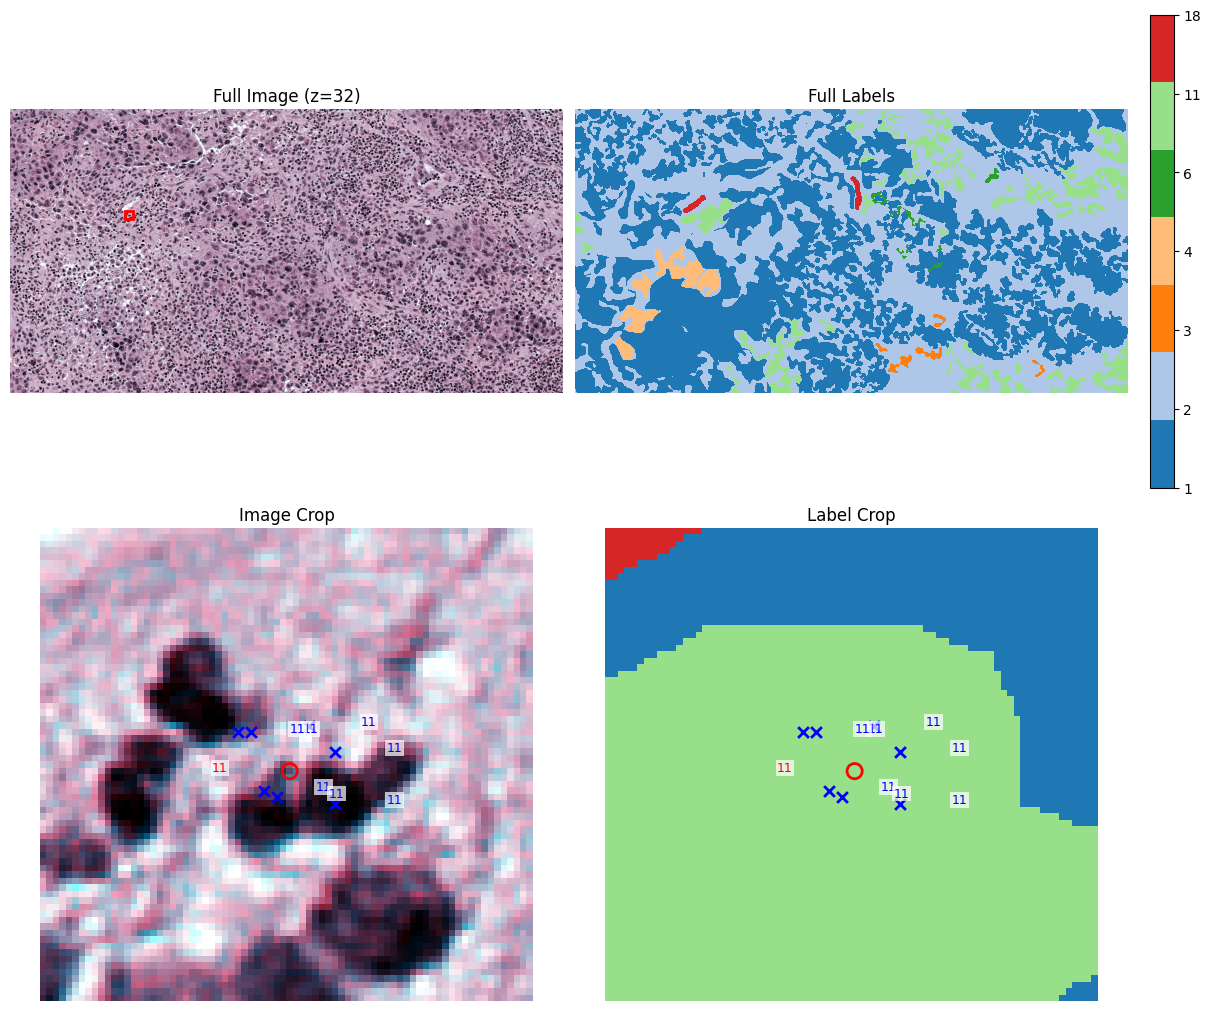

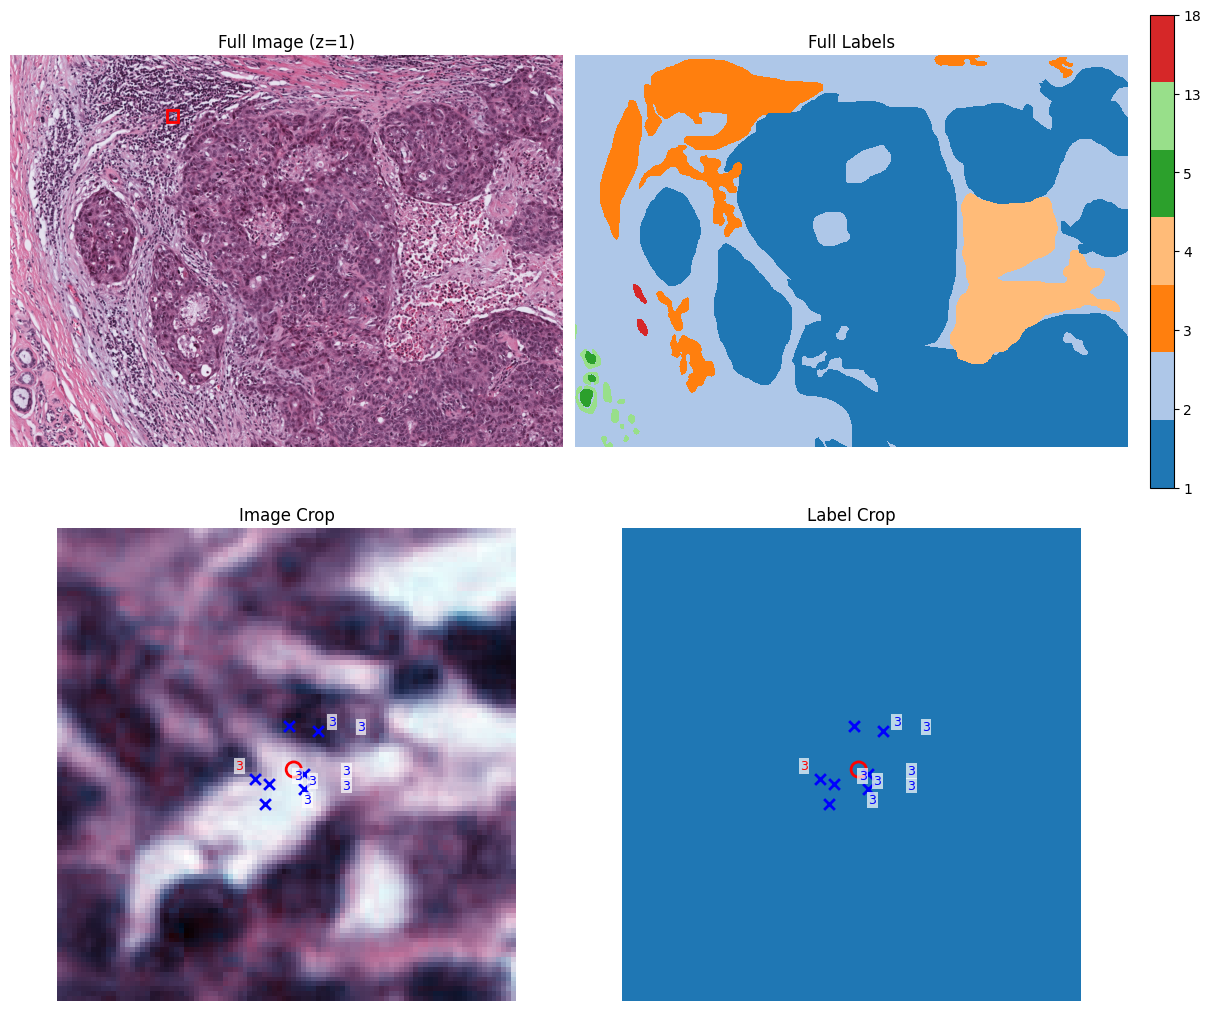

In [19]:
# By anchor label (random group with that anchor label)
plot_full_and_crop_with_box(train_set, label=11, pad=30)

# Or by explicit group index
plot_full_and_crop_with_box(train_set, idx=123, pad=40, robust=False)


In [ ]:
train_loader = DataLoader(
    train_set,
    batch_sampler=ModeAwareBalancedAnchorBatchSampler(
        train_set, total_patches_per_batch=batch_size, shuffle=True
    ),
    collate_fn=flex_collate,
)

img_shape = (64, 64)

model = LadderVAE(
    z_dims=z_dims,
    blocks_per_layer=blocks_per_layer,
    data_mean=data_mean,
    data_std=data_std,
    noiseModel=noiseModel,
    conv_mult=2,
    device=device,
    batchnorm=batchnorm,
    free_bits=free_bits,
    img_shape=img_shape,
    grad_checkpoint=True,
    mask_size=initial_mask_size,
    contrastive_learning=contrastive_learning,
    margin=margin,
    lambda_contrastive=lambda_contrastive,
    stochastic_block_type=stochastic_block_type,
    conditional=conditional,
    condition_type=condition_type,
    n_components=n_components,
    training_mode=mode,
    labeled_ratio=labeled_ratio,
).cuda()
print(model)
model.train()  # Model set in training mode

training.train_network(
    model=model,
    lr=lr,
    max_epochs=max_epochs,
    directory_path=directory_path,
    batch_size=batch_size,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    train_loader=train_loader,
    val_loader=val_loader,
    gaussian_noise_std=gaussian_noise_std,
    model_name=model_name,
    gradient_scale=256,
    use_wandb=use_wandb,
    max_grad_norm=1,
    initial_label_size=initial_label_size,
    final_label_size=final_label_size,
    initial_mask_size=initial_mask_size,
    final_mask_size=final_mask_size,
    step_interval=step_interval,
)
